Iniciando procesamiento de datos...
Dataset original cargado con 106887 registros.
Dataset filtrado (Biobío y Ñuble) contiene 13843 registros.
Realizando imputación inteligente y limpieza...
Eliminando columnas 100% nulas: ['TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS', 'TOTAL MATRÍCULA NO BINARIOS O INDEFINIDOS PRIMER AÑO', 'PROMEDIO EDAD NO BINARIO']
Generando visualizaciones...

DATOS GRAFICO 1: Matrícula por Tipo de Institución y Región
CLASIFICACIÓN INSTITUCIÓN NIVEL 1  CENTROS DE FORMACIÓN TÉCNICA  \
Region_Limpia                                                     
Biobío                                                     1443   
Ñuble                                                       387   

CLASIFICACIÓN INSTITUCIÓN NIVEL 1  INSTITUTOS PROFESIONALES  UNIVERSIDADES  
Region_Limpia                                                               
Biobío                                                 3960           6072  
Ñuble                                                   7

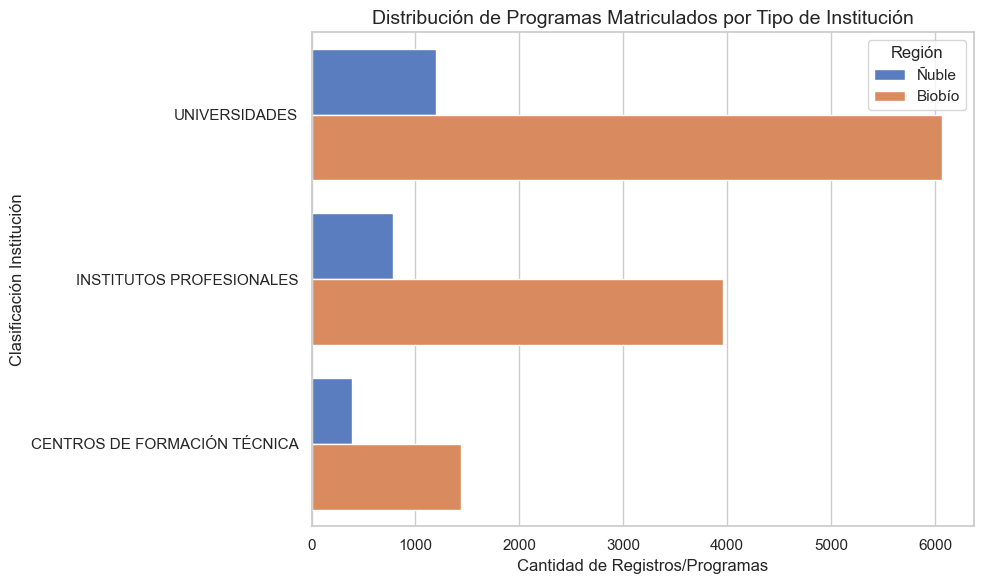


DATOS GRAFICO 2: Edad Promedio de la Carrera por Región y Tipo de Institución
                                                  count       mean       std  \
Region_Limpia CLASIFICACIÓN INSTITUCIÓN NIVEL 1                                
Biobío        CENTROS DE FORMACIÓN TÉCNICA       1443.0  26.610118  5.231189   
              INSTITUTOS PROFESIONALES           3960.0  27.958460  5.754433   
              UNIVERSIDADES                      6072.0  28.400856  6.257284   
Ñuble         CENTROS DE FORMACIÓN TÉCNICA        387.0  23.837468  3.442491   
              INSTITUTOS PROFESIONALES            783.0  28.329374  5.844862   
              UNIVERSIDADES                      1198.0  26.954424  6.077504   

                                                  min   max  
Region_Limpia CLASIFICACIÓN INSTITUCIÓN NIVEL 1              
Biobío        CENTROS DE FORMACIÓN TÉCNICA       18.5  56.0  
              INSTITUTOS PROFESIONALES           18.0  59.0  
              UNIVERSIDADES     

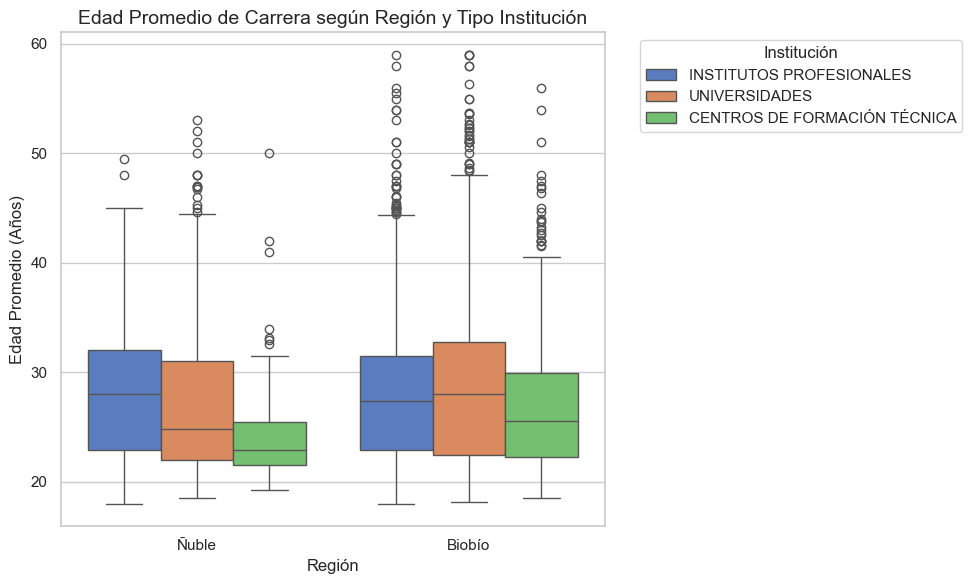


DATOS GRAFICO 3: Brecha de Género (Ratio de Mujeres) por Área del Conocimiento
                                          count      mean       std       min  \
Region_Limpia ÁREA DEL CONOCIMIENTO                                             
Biobío        ADMINISTRACIÓN Y COMERCIO  2194.0  0.582795  0.182551  0.049383   
              AGROPECUARIA                182.0  0.550880  0.192904  0.055556   
              ARTE Y ARQUITECTURA         312.0  0.633219  0.254861  0.061224   
              CIENCIAS BÁSICAS            494.0  0.434725  0.178772  0.026316   
              CIENCIAS SOCIALES          1063.0  0.701651  0.186841  0.033333   
              DERECHO                     253.0  0.540316  0.183044  0.200000   
              EDUCACIÓN                  1543.0  0.800368  0.253309  0.035714   
              HUMANIDADES                 162.0  0.592342  0.206480  0.111111   
              SALUD                      1610.0  0.723305  0.207752  0.058824   
              TECNOLOGÍA     

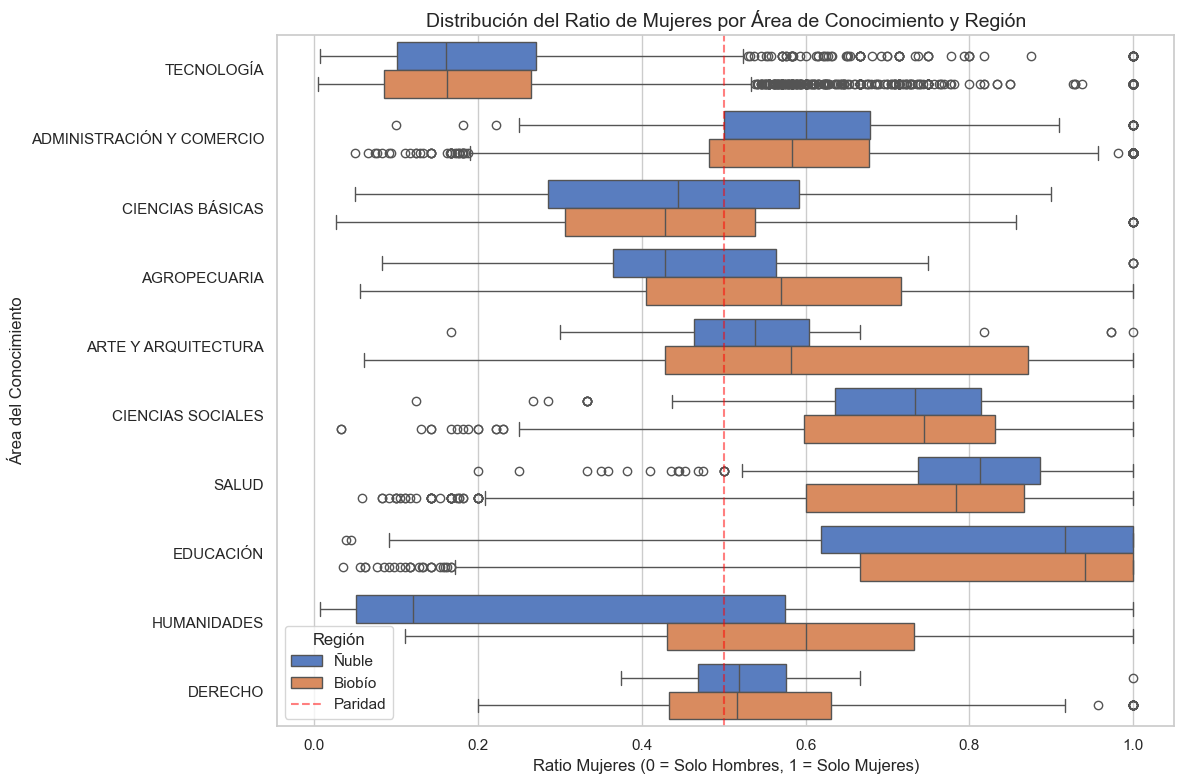

Proceso finalizado. Archivo guardado exitosamente: dataMatricula_Biobio_Nuble.csv
Gráficas guardadas: distribucion_institucion_region.png, edad_promedio_region_institucion.png, ratio_mujeres_area_conocimiento.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Disable warnings for cleaner output
warnings.filterwarnings('ignore')

def main():
    print("Iniciando procesamiento de datos...")
    
    # 1. Carga de datos con manejo de encoding
    try:
        df = pd.read_csv('dataMatricula_clean.csv', sep=',', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv('dataMatricula_clean.csv', sep=',', encoding='latin1')
        
    print(f"Dataset original cargado con {len(df)} registros.")

    # 2. Zonificación: Filtrar por Biobío y Ñuble
    # Buscar la columna de región independientemente de problemas de encoding
    region_col = [c for c in df.columns if 'regi' in c.lower()][0]
    
    # Filtrar usando coincidencias parciales para evitar errores de encoding
    df_zonas = df[df[region_col].str.contains('UBLE|BIOB', na=False, case=False)].copy()
    print(f"Dataset filtrado (Biobío y Ñuble) contiene {len(df_zonas)} registros.")
    
    # Arreglar los nombres de las regiones para estandarizarlos
    def clean_region(val):
        if pd.isna(val): return val
        val_upper = val.upper()
        if 'UBLE' in val_upper: return 'Ñuble'
        if 'BIOB' in val_upper: return 'Biobío'
        return val
        
    df_zonas['Region_Limpia'] = df_zonas[region_col].apply(clean_region)

    # 3. Limpieza e Imputación Inteligente
    print("Realizando imputación inteligente y limpieza...")
    
    # A. Eliminar columnas 100% nulas
    cols_to_drop = [
        col for col in df_zonas.columns 
        if 'NO BINARIO' in col.upper() and df_zonas[col].isnull().all()
    ]
    if cols_to_drop:
        print(f"Eliminando columnas 100% nulas: {cols_to_drop}")
        df_zonas.drop(columns=cols_to_drop, inplace=True)
        
    # B. Rellenar recuentos demográficos faltantes con 0
    count_cols_keywords = ['TOTAL MATR', 'RANGO DE EDAD', 'TES ', 'TIPO ESTABLECIMIENTO', 'CLAS_EST']
    count_cols = [c for c in df_zonas.columns if any(k in c.upper() for k in count_cols_keywords) and df_zonas[c].dtype in [np.float64, np.int64]]
    
    for col in count_cols:
        df_zonas[col].fillna(0, inplace=True)

    # C. Limpiar formato de columnas de promedio de edad y convertirlas a float
    age_avg_cols = [c for c in df_zonas.columns if 'PROMEDIO EDAD' in c.upper()]
    for col in age_avg_cols:
        if df_zonas[col].dtype == 'object':
            df_zonas[col] = df_zonas[col].astype(str).str.replace(',', '.').astype(float)
            
    # D. Imputación: Mediana Agrupada
    # Usaremos la mediana de la Región y Clasificación de Institución (Ej. Univ, IP, CFT)
    clasif_col = 'CLASIFICACIÓN INSTITUCIÓN NIVEL 1'
    
    for col in age_avg_cols:
        if df_zonas[col].isnull().any():
            # Agrupar por Región y Clasificación de Institución y calcular mediana
            median_by_group = df_zonas.groupby(['Region_Limpia', clasif_col])[col].transform('median')
            
            # Imputar valores
            df_zonas[col].fillna(median_by_group, inplace=True)
            
            # Si aún quedan nulos (porque no hay datos para ese grupo), usar la mediana global
            if df_zonas[col].isnull().any():
                df_zonas[col].fillna(df_zonas[col].median(), inplace=True)

    # Revisar si hay ratio de mujeres que imputar
    if 'RATIO_MUJERES' in df_zonas.columns:
        median_ratio = df_zonas.groupby(['Region_Limpia', 'ÁREA DEL CONOCIMIENTO'])['RATIO_MUJERES'].transform('median')
        df_zonas['RATIO_MUJERES'].fillna(median_ratio, inplace=True)
        df_zonas['RATIO_MUJERES'].fillna(0, inplace=True)

    # 4. Generación de Distribuciones Críticas
    print("Generando visualizaciones...")
    sns.set_theme(style="whitegrid", palette="muted")
    
    # Grafico 1: Matrícula por Tipo de Institución y Región
    print("\n" + "="*50)
    print("DATOS GRAFICO 1: Matrícula por Tipo de Institución y Región")
    print(df_zonas.groupby(['Region_Limpia', clasif_col]).size().unstack(fill_value=0))
    print("="*50 + "\n")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_zonas, y=clasif_col, hue='Region_Limpia', order=df_zonas[clasif_col].value_counts().index)
    plt.title('Distribución de Programas Matriculados por Tipo de Institución', fontsize=14)
    plt.xlabel('Cantidad de Registros/Programas')
    plt.ylabel('Clasificación Institución')
    plt.legend(title='Región')
    plt.tight_layout()
    plt.savefig('distribucion_institucion_region.png', dpi=300)
    plt.show()
    
    # Grafico 2: Edad Promedio de la Carrera por Región y Tipo de Institución
    age_col = [c for c in age_avg_cols if 'CARRERA' in c.upper()][0]
    print("\n" + "="*50)
    print("DATOS GRAFICO 2: Edad Promedio de la Carrera por Región y Tipo de Institución")
    print(df_zonas.groupby(['Region_Limpia', clasif_col])[age_col].describe()[['count', 'mean', 'std', 'min', 'max']])
    print("="*50 + "\n")
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_zonas, x='Region_Limpia', y=age_col, hue=clasif_col)
    plt.title('Edad Promedio de Carrera según Región y Tipo Institución', fontsize=14)
    plt.xlabel('Región')
    plt.ylabel('Edad Promedio (Años)')
    plt.legend(title='Institución', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('edad_promedio_region_institucion.png', dpi=300)
    plt.show()

    # Grafico 3: Brecha de Género (Ratio de Mujeres) por Área del Conocimiento
    print("\n" + "="*50)
    print("DATOS GRAFICO 3: Brecha de Género (Ratio de Mujeres) por Área del Conocimiento")
    print(df_zonas.groupby(['Region_Limpia', 'ÁREA DEL CONOCIMIENTO'])['RATIO_MUJERES'].describe()[['count', 'mean', 'std', 'min', 'max']])
    print("="*50 + "\n")
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df_zonas, y='ÁREA DEL CONOCIMIENTO', x='RATIO_MUJERES', hue='Region_Limpia')
    plt.title('Distribución del Ratio de Mujeres por Área de Conocimiento y Región', fontsize=14)
    plt.xlabel('Ratio Mujeres (0 = Solo Hombres, 1 = Solo Mujeres)')
    plt.ylabel('Área del Conocimiento')
    plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Paridad')
    plt.legend(title='Región')
    plt.tight_layout()
    plt.savefig('ratio_mujeres_area_conocimiento.png', dpi=300)
    plt.show()

    # 5. Guardar CSV Final
    output_file = 'dataMatricula_Biobio_Nuble.csv'
    df_zonas.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Proceso finalizado. Archivo guardado exitosamente: {output_file}")
    print("Gráficas guardadas: distribucion_institucion_region.png, edad_promedio_region_institucion.png, ratio_mujeres_area_conocimiento.png")

if __name__ == "__main__":
    main()

Iniciando procesamiento de datos de Admisión...
Dataset de Admisión original cargado con 2655680 registros.
Dataset de Admisión filtrado (Instituciones Biobío/Ñuble - 1ra Pref) contiene 176913 registros.
Realizando imputación inteligente y limpieza en Admisión...
Eliminando 5 columnas 100% nulas.
Generando visualizaciones de Admisión...

DATOS GRAFICO 1 ADMISIÓN: Estado de la 1ra Preferencia
ESTADO_PREF_01
25.0    92739
24.0    58907
17.0    10921
36.0     7627
31.0     4202
30.0      723
29.0      377
40.0      366
35.0      267
42.0      202
9.0       162
20.0      161
27.0      100
28.0       73
37.0       41
23.0       36
32.0        9
Name: count, dtype: int64



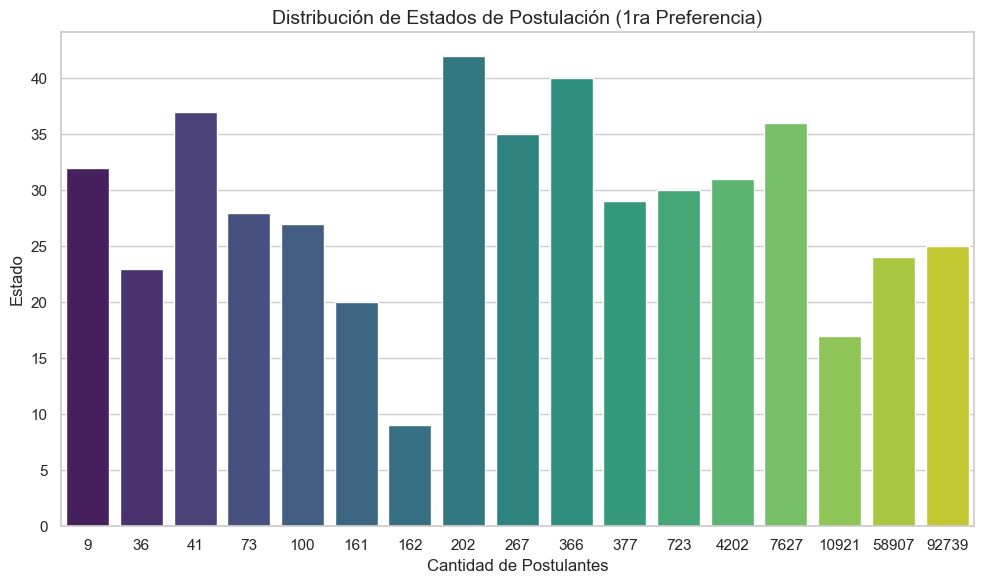


DATOS GRAFICO 2 ADMISIÓN: Estadísticas de Puntajes (1ra Preferencia)
count    176913.000000
mean        602.500825
std         150.555840
min           0.000000
max         838.600000
Name: PTJE_PREF01, dtype: float64



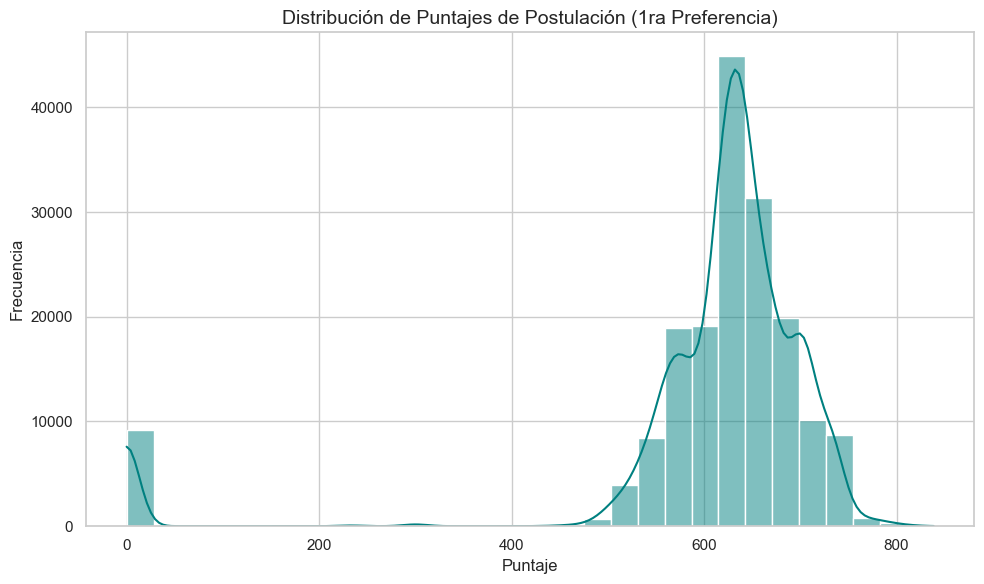


Proceso de Admisión finalizado. Archivo guardado exitosamente: dataAdmision_Biobio_Nuble.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def process_admision_corregido():
    print("Iniciando procesamiento de datos de Admisión...")

    # 1. Cargar datos de Admisión
    try:
        df_adm = pd.read_csv('dataAdmision.csv', sep=',', encoding='utf-8', low_memory=False)
    except UnicodeDecodeError:
        df_adm = pd.read_csv('dataAdmision.csv', sep=',', encoding='latin1', low_memory=False)
        
    print(f"Dataset de Admisión original cargado con {len(df_adm)} registros.")

    # 2. Zonificación por Prefijo DEMRE (Biobío y Ñuble)
    # Los 2 primeros dígitos del código de carrera del DEMRE indican la universidad.
    # 11 = UdeC, 16 = UBB, 34 = UCSC, 17 = U. de Talca (Sede Chillán)
    prefijos_zona = ['11', '16', '34', '17']
    
    # Convertir a string para extraer el prefijo, rellenando nulos con 0
    codigos_str = df_adm['COD_CARRERA_PREF_01'].fillna(0).astype(int).astype(str)
    
    # Filtrar si los códigos de carrera empiezan con alguno de los prefijos
    mascara_zona = codigos_str.str[:2].isin(prefijos_zona)
    df_adm_zonas = df_adm[mascara_zona].copy()
    
    print(f"Dataset de Admisión filtrado (Instituciones Biobío/Ñuble - 1ra Pref) contiene {len(df_adm_zonas)} registros.")

    if len(df_adm_zonas) == 0:
        print("Error: Sigue sin haber registros. Revisa el formato de los datos.")
        return

    # 3. Limpieza e Imputación Inteligente
    print("Realizando imputación inteligente y limpieza en Admisión...")
    
    # A. Eliminar columnas 100% nulas
    cols_to_drop = [col for col in df_adm_zonas.columns if df_adm_zonas[col].isnull().all()]
    if cols_to_drop:
        print(f"Eliminando {len(cols_to_drop)} columnas 100% nulas.")
        df_adm_zonas.drop(columns=cols_to_drop, inplace=True)

    # B. Imputación y casteo del Puntaje de la Preferencia 1
    if 'PTJE_PREF01' in df_adm_zonas.columns:
        # Reemplazar comas por puntos si viene como string
        if df_adm_zonas['PTJE_PREF01'].dtype == 'object':
            df_adm_zonas['PTJE_PREF01'] = df_adm_zonas['PTJE_PREF01'].astype(str).str.replace(',', '.').astype(float)
            
        # Imputar valores nulos con la mediana agrupada por la carrera preferida
        if df_adm_zonas['PTJE_PREF01'].isnull().any():
            median_by_career = df_adm_zonas.groupby('COD_CARRERA_PREF_01')['PTJE_PREF01'].transform('median')
            df_adm_zonas['PTJE_PREF01'].fillna(median_by_career, inplace=True)
            
            # Si aún hay nulos, usar mediana global
            if df_adm_zonas['PTJE_PREF01'].isnull().any():
                df_adm_zonas['PTJE_PREF01'].fillna(df_adm_zonas['PTJE_PREF01'].median(), inplace=True)

    # 4. Generación de Distribuciones Críticas
    print("Generando visualizaciones de Admisión...")
    sns.set_theme(style="whitegrid", palette="muted")

    # Grafico 1: Estado de la Postulación de 1ra Preferencia
    if 'ESTADO_PREF_01' in df_adm_zonas.columns:
        print("\n" + "="*50)
        print("DATOS GRAFICO 1 ADMISIÓN: Estado de la 1ra Preferencia")
        estado_counts = df_adm_zonas['ESTADO_PREF_01'].value_counts()
        print(estado_counts)
        print("="*50 + "\n")
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=estado_counts.values, y=estado_counts.index, palette="viridis")
        plt.title('Distribución de Estados de Postulación (1ra Preferencia)', fontsize=14)
        plt.xlabel('Cantidad de Postulantes')
        plt.ylabel('Estado')
        plt.tight_layout()
        plt.savefig('admision_estado_pref_01.png', dpi=300)
        plt.show()

    # Grafico 2: Distribución de Puntajes de 1ra Preferencia
    if 'PTJE_PREF01' in df_adm_zonas.columns:
        print("\n" + "="*50)
        print("DATOS GRAFICO 2 ADMISIÓN: Estadísticas de Puntajes (1ra Preferencia)")
        print(df_adm_zonas['PTJE_PREF01'].describe()[['count', 'mean', 'std', 'min', 'max']])
        print("="*50 + "\n")
        
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df_adm_zonas, x='PTJE_PREF01', bins=30, kde=True, color='teal')
        plt.title('Distribución de Puntajes de Postulación (1ra Preferencia)', fontsize=14)
        plt.xlabel('Puntaje')
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.savefig('admision_puntaje_pref_01.png', dpi=300)
        plt.show()

    # 5. Guardar CSV Final
    output_file = 'dataAdmision_Biobio_Nuble.csv'
    df_adm_zonas.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\nProceso de Admisión finalizado. Archivo guardado exitosamente: {output_file}")

# Ejecutar la función corregida
process_admision_corregido()


Carga de Datos y Zonificación: Para aislar la data de Biobío y Ñuble solucionando los errores de formato.

Imputación Inteligente: Para limpiar los nulos llenando los recuentos con 0 y los numéricos promediados usando la mediana según la clasificación de la institución.

Visualización de Distribuciones: Aquí están programadas tres distribuciones clave utilizando plt.show() que apoyan directamente la toma de decisiones:
- Preferencia de Tipo de Institución (para decisiones de promoción/alcance).
- Edad promedio por Tipo de Institución (para dirigir el público objetivo de marketing educativo).
- Brecha de género (Ratio de mujeres) según el área de conocimiento (para políticas de inclusión y diversidad).